# YOLO26 Trade-off (Nano to XLarge) from runs/detect
Notebook ini memvisualisasikan trade-off antar varian model YOLO26 (`n`, `s`, `m`, `l`, `x`) berdasarkan hasil training pada `ai/research/runs/detect`.

Fokus trade-off:
- Akurasi: `metrics/mAP50(B)`, `metrics/mAP50-95(B)`, `precision`, `recall`
- Biaya: total waktu training (proxy compute cost)
- Kompleksitas model: ukuran file `.pt` (MB)

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
# Resolve ai/ root by walking up until we find a dir with both 'models' and 'research'.
cwd = Path.cwd().resolve()
ai_dir = next(
    p for p in [cwd, *cwd.parents]
    if (p / "models").is_dir() and (p / "research").is_dir()
)

runs_root = ai_dir / "research" / "runs" / "detect"
models_root = ai_dir / "models"

variant_order = ["n", "s", "m", "l", "x"]
variant_label = {"n": "Nano", "s": "Small", "m": "Medium", "l": "Large", "x": "XLarge"}

runs_root, models_root

(WindowsPath('C:/Users/istd.magang125/Documents/cctv-insight/ai/research/runs/detect'),
 WindowsPath('C:/Users/istd.magang125/Documents/cctv-insight/ai/models'))

In [3]:
records = []

for run_dir in sorted(runs_root.glob("face_mask_yolo26*")):
    results_csv = run_dir / "results.csv"
    args_yaml = run_dir / "args.yaml"
    if not results_csv.exists() or not args_yaml.exists():
        continue

    variant = run_dir.name[-1].lower()

    df = pd.read_csv(results_csv)
    best_idx = df["metrics/mAP50-95(B)"].idxmax()
    best_row = df.loc[best_idx]
    final_row = df.iloc[-1]

    # Parse model path from args.yaml without external dependency.
    model_path = None
    for line in args_yaml.read_text(encoding="utf-8").splitlines():
        if line.startswith("model:"):
            model_path = line.split(":", 1)[1].strip()
            break

    model_file = models_root / f"yolo26{variant}.pt"
    model_size_mb = model_file.stat().st_size / (1024 ** 2) if model_file.exists() else np.nan

    records.append({
        "variant": variant,
        "variant_name": variant_label.get(variant, variant.upper()),
        "run_name": run_dir.name,
        "epochs_trained": int(final_row["epoch"]),
        "total_train_time_sec": float(final_row["time"]),
        "avg_epoch_time_sec": float(final_row["time"]) / max(int(final_row["epoch"]), 1),
        "best_epoch": int(best_row["epoch"]),
        "best_precision": float(best_row["metrics/precision(B)"]),
        "best_recall": float(best_row["metrics/recall(B)"]),
        "best_map50": float(best_row["metrics/mAP50(B)"]),
        "best_map50_95": float(best_row["metrics/mAP50-95(B)"]),
        "final_map50_95": float(final_row["metrics/mAP50-95(B)"]),
        "model_path_from_args": model_path,
        "model_size_mb": model_size_mb,
    })

summary = pd.DataFrame(records)
summary["variant"] = pd.Categorical(summary["variant"], categories=variant_order, ordered=True)
summary = summary.sort_values("variant").reset_index(drop=True)
summary

,variant,variant_name,run_name,epochs_trained,total_train_time_sec,avg_epoch_time_sec,best_epoch,best_precision,best_recall,best_map50,best_map50_95,final_map50_95,model_path_from_args,model_size_mb
0,n,Nano,face_mask_yolo26n,50,755.816,15.11632,49,0.78253,0.77198,0.83365,0.37719,0.37257,c:\Users\istd.magang125\Documents\cctv-insight...,5.287602
1,s,Small,face_mask_yolo26s,50,1152.020,23.04040,49,0.82331,0.82303,0.86973,0.41462,0.41320,c:\Users\istd.magang125\Documents\cctv-insight...,19.476628
2,m,Medium,face_mask_yolo26m,50,14265.900,285.31800,49,0.86493,0.83142,0.89651,0.42784,0.42544,c:\Users\istd.magang125\Documents\cctv-insight...,42.205529
3,l,Large,face_mask_yolo26l,50,20444.600,408.89200,49,0.85550,0.83447,0.89153,0.42346,0.42159,c:\Users\istd.magang125\Documents\cctv-insight...,50.746129
4,x,XLarge,face_mask_yolo26x,50,54102.800,1082.05600,49,0.83820,0.84311,0.88145,0.42105,0.41751,c:\Users\istd.magang125\Documents\cctv-insight...,113.170018


In [4]:
display_cols = [
    "variant_name",
    "model_size_mb",
    "best_map50",
    "best_map50_95",
    "best_precision",
    "best_recall",
    "total_train_time_sec",
    "avg_epoch_time_sec",
]

table = summary[display_cols].copy()
table["model_size_mb"] = table["model_size_mb"].round(2)
table[["best_map50", "best_map50_95", "best_precision", "best_recall"]] = table[["best_map50", "best_map50_95", "best_precision", "best_recall"]].round(4)
table[["total_train_time_sec", "avg_epoch_time_sec"]] = table[["total_train_time_sec", "avg_epoch_time_sec"]].round(2)
table

,variant_name,model_size_mb,best_map50,best_map50_95,best_precision,best_recall,total_train_time_sec,avg_epoch_time_sec
0,Nano,5.29,0.8336,0.3772,0.7825,0.7720,755.82,15.12
1,Small,19.48,0.8697,0.4146,0.8233,0.8230,1152.02,23.04
2,Medium,42.21,0.8965,0.4278,0.8649,0.8314,14265.90,285.32
3,Large,50.75,0.8915,0.4235,0.8555,0.8345,20444.60,408.89
4,XLarge,113.17,0.8814,0.4210,0.8382,0.8431,54102.80,1082.06


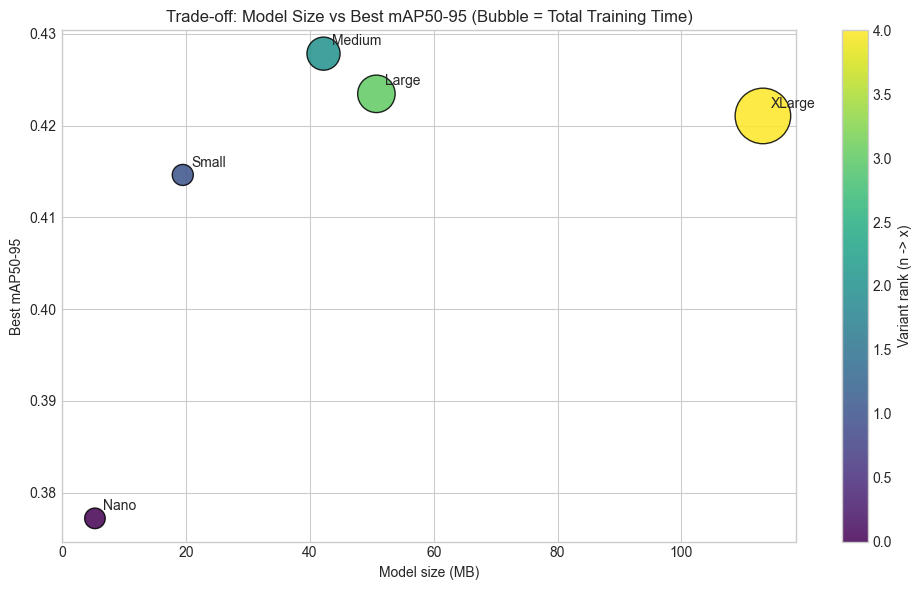

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

x = summary["model_size_mb"]
y = summary["best_map50_95"]
size = (summary["total_train_time_sec"] / summary["total_train_time_sec"].max()) * 1400 + 200

scatter = ax.scatter(x, y, s=size, c=range(len(summary)), cmap="viridis", alpha=0.85, edgecolors="black")

for _, row in summary.iterrows():
    ax.annotate(row["variant_name"], (row["model_size_mb"], row["best_map50_95"]), xytext=(6, 6), textcoords="offset points")

ax.set_title("Trade-off: Model Size vs Best mAP50-95 (Bubble = Total Training Time)")
ax.set_xlabel("Model size (MB)")
ax.set_ylabel("Best mAP50-95")

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Variant rank (n -> x)")

plt.tight_layout()
plt.show()

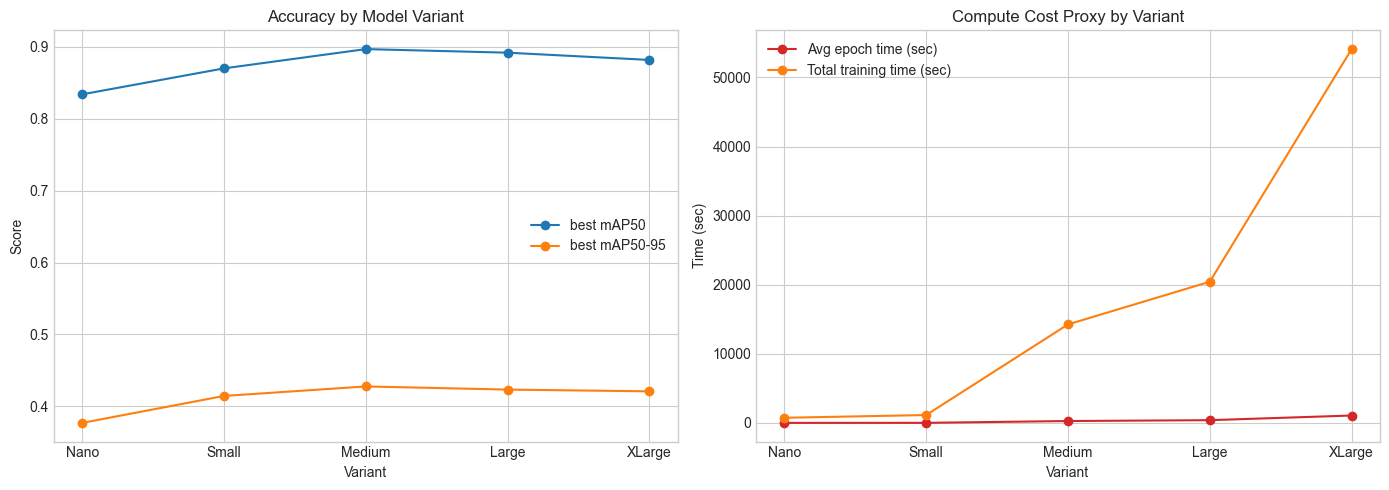

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(summary["variant_name"], summary["best_map50"], marker="o", label="best mAP50")
axes[0].plot(summary["variant_name"], summary["best_map50_95"], marker="o", label="best mAP50-95")
axes[0].set_title("Accuracy by Model Variant")
axes[0].set_xlabel("Variant")
axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].plot(summary["variant_name"], summary["avg_epoch_time_sec"], marker="o", color="tab:red", label="Avg epoch time (sec)")
axes[1].plot(summary["variant_name"], summary["total_train_time_sec"], marker="o", color="tab:orange", label="Total training time (sec)")
axes[1].set_title("Compute Cost Proxy by Variant")
axes[1].set_xlabel("Variant")
axes[1].set_ylabel("Time (sec)")
axes[1].legend()

plt.tight_layout()
plt.show()

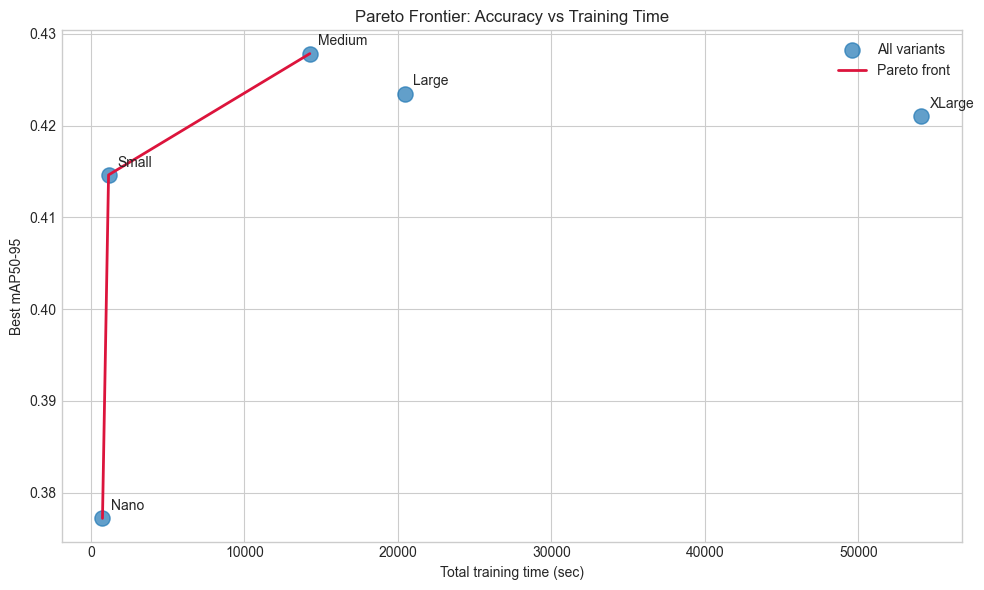

,variant_name,best_map50_95,total_train_time_sec,is_pareto
0,Nano,0.37719,755.816,True
1,Small,0.41462,1152.020,True
2,Medium,0.42784,14265.900,True


In [7]:
# Pareto front: maximize mAP50-95, minimize total training time.
trade = summary[["variant_name", "best_map50_95", "total_train_time_sec"]].copy()

is_pareto = []
for i, row_i in trade.iterrows():
    dominated = False
    for j, row_j in trade.iterrows():
        if i == j:
            continue
        better_or_equal_acc = row_j["best_map50_95"] >= row_i["best_map50_95"]
        better_or_equal_time = row_j["total_train_time_sec"] <= row_i["total_train_time_sec"]
        strictly_better_one = (row_j["best_map50_95"] > row_i["best_map50_95"]) or (row_j["total_train_time_sec"] < row_i["total_train_time_sec"])
        if better_or_equal_acc and better_or_equal_time and strictly_better_one:
            dominated = True
            break
    is_pareto.append(not dominated)

trade["is_pareto"] = is_pareto
pareto = trade[trade["is_pareto"]].sort_values("total_train_time_sec")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(trade["total_train_time_sec"], trade["best_map50_95"], s=120, alpha=0.7, label="All variants")
ax.plot(pareto["total_train_time_sec"], pareto["best_map50_95"], color="crimson", linewidth=2, label="Pareto front")

for _, row in trade.iterrows():
    ax.annotate(row["variant_name"], (row["total_train_time_sec"], row["best_map50_95"]), xytext=(6, 6), textcoords="offset points")

ax.set_title("Pareto Frontier: Accuracy vs Training Time")
ax.set_xlabel("Total training time (sec)")
ax.set_ylabel("Best mAP50-95")
ax.legend()

plt.tight_layout()
plt.show()

pareto

## Interpretasi Cepat
Gunakan panduan berikut saat membaca hasil:
1. Jika target Anda latency/biaya komputasi rendah, prioritaskan model di sisi kiri-bawah (waktu/ukuran kecil) dengan mAP masih acceptable.
2. Jika target Anda akurasi maksimum, lihat model dengan mAP tertinggi, lalu cek kenaikan waktu training yang harus dibayar.
3. Titik pada Pareto front adalah kandidat terbaik untuk kompromi biaya vs akurasi.

## Performa AI: Face Mask CCTV vs People Counting
Bagian ini menambahkan evaluasi performa AI untuk dua skenario:
1. Face mask detection pada dataset face_mask_cctv.
2. People counting (proxy) dari hasil inferensi jumlah orang.

Catatan: perbandingan people counting antar varian saat ini tersedia untuk `yolo26l`, `yolo26m`, dan `yolo26x` berdasarkan artifact yang ada.

In [8]:
artifacts_root = ai_dir / "research" / "artifacts"

face_eval = pd.read_csv(artifacts_root / "face_mask" / "all_variants_face_eval.csv")
people_proxy_eval = pd.read_csv(artifacts_root / "face_mask" / "all_variants_people_proxy_eval.csv")

# Normalize variant label for consistent ordering.
for _df in (face_eval, people_proxy_eval):
    _df["variant"] = _df["variant"].str.replace("yolo26", "", regex=False)
    _df["variant"] = pd.Categorical(_df["variant"], categories=variant_order, ordered=True)
    _df.sort_values("variant", inplace=True)

face_eval

,variant,map50_face,map50_95_face,precision_face,recall_face,preprocess_ms_face,inference_ms_face,postprocess_ms_face,total_ms_face,fps_face
1,m,0.838901,0.392940,0.860423,0.849241,0.594743,9.516786,0.131057,10.242587,97.631585
0,l,0.828085,0.391641,0.826219,0.864435,0.496379,9.879255,0.131345,10.506980,95.174831
2,x,0.836265,0.395712,0.867292,0.848207,0.479519,19.069318,0.119009,19.667846,50.844409


In [9]:
people_proxy_eval

,variant,samples,proxy_mae_count,proxy_rmse_count,proxy_exact_count_acc,proxy_within1_count_acc,avg_pred_boxes,avg_gt_people,inference_ms_people,fps_people
1,m,760,3.239474,8.604161,0.151316,0.572368,0.353947,3.525,13.038700,76.694764
0,l,760,3.273684,8.599878,0.131579,0.563158,0.325000,3.525,15.729137,63.576277
2,x,760,3.285526,8.597047,0.131579,0.552632,0.307895,3.525,22.463760,44.516145


In [ ]:
import json

people_eval_report_path = artifacts_root / "people_counting" / "eval_report.json"
people_eval_metrics = json.loads(people_eval_report_path.read_text(encoding="utf-8"))["metrics"]

pd.DataFrame([people_eval_metrics]).round(4)

In [10]:
# Join the two tasks into one comparison table.
combined_perf = pd.merge(
    face_eval[["variant", "map50_face", "map50_95_face", "precision_face", "recall_face", "fps_face", "total_ms_face"]],
    people_proxy_eval[["variant", "proxy_mae_count", "proxy_rmse_count", "proxy_exact_count_acc", "proxy_within1_count_acc", "fps_people", "inference_ms_people"]],
    on="variant",
    how="outer"
)

combined_perf["variant_name"] = combined_perf["variant"].astype(str).map(variant_label)
combined_perf = combined_perf.sort_values("variant").reset_index(drop=True)

cols = [
    "variant_name",
    "map50_face",
    "map50_95_face",
    "precision_face",
    "recall_face",
    "fps_face",
    "proxy_mae_count",
    "proxy_rmse_count",
    "proxy_exact_count_acc",
    "proxy_within1_count_acc",
    "fps_people",
]

combined_perf[cols].round(4)

,variant_name,map50_face,map50_95_face,precision_face,recall_face,fps_face,proxy_mae_count,proxy_rmse_count,proxy_exact_count_acc,proxy_within1_count_acc,fps_people
0,Medium,0.8389,0.3929,0.8604,0.8492,97.6316,3.2395,8.6042,0.1513,0.5724,76.6948
1,Large,0.8281,0.3916,0.8262,0.8644,95.1748,3.2737,8.5999,0.1316,0.5632,63.5763
2,XLarge,0.8363,0.3957,0.8673,0.8482,50.8444,3.2855,8.5970,0.1316,0.5526,44.5161


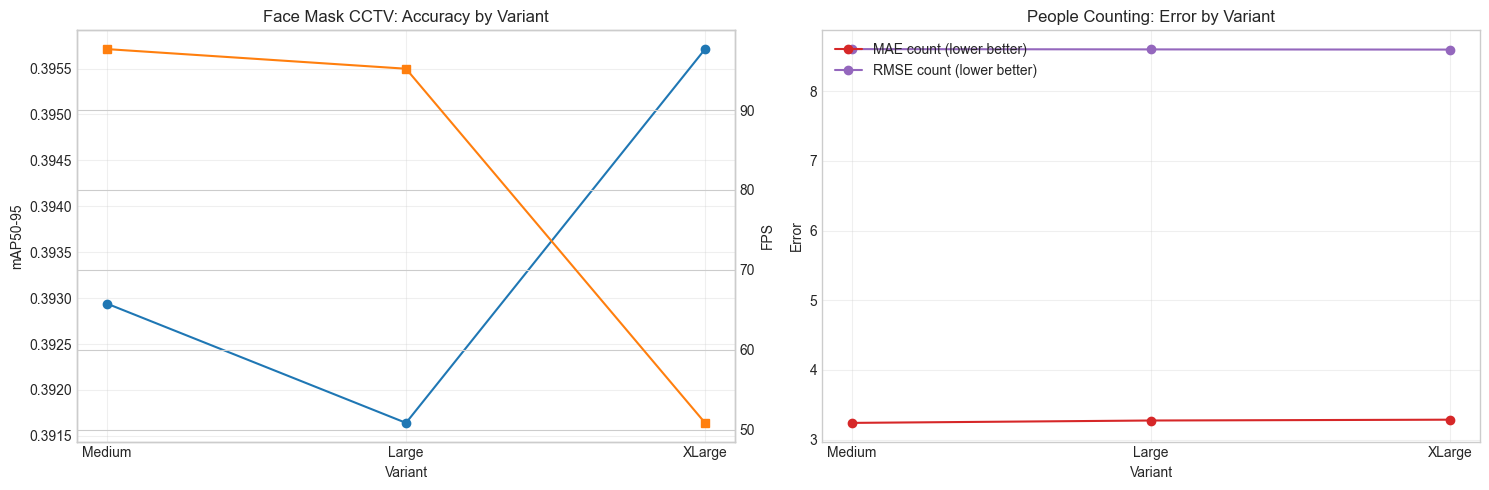

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Face mask performance: accuracy vs speed.
axes[0].plot(combined_perf["variant_name"], combined_perf["map50_95_face"], marker="o", label="mAP50-95 (face)")
axes[0].set_title("Face Mask CCTV: Accuracy by Variant")
axes[0].set_xlabel("Variant")
axes[0].set_ylabel("mAP50-95")
axes[0].grid(True, alpha=0.3)

ax0b = axes[0].twinx()
ax0b.plot(combined_perf["variant_name"], combined_perf["fps_face"], marker="s", color="tab:orange", label="FPS (face)")
ax0b.set_ylabel("FPS")

# People counting proxy performance (available variants only).
pp = combined_perf.dropna(subset=["proxy_mae_count"]).copy()
axes[1].plot(pp["variant_name"], pp["proxy_mae_count"], marker="o", color="tab:red", label="MAE count (lower better)")
axes[1].plot(pp["variant_name"], pp["proxy_rmse_count"], marker="o", color="tab:purple", label="RMSE count (lower better)")
axes[1].set_title("People Counting: Error by Variant")
axes[1].set_xlabel("Variant")
axes[1].set_ylabel("Error")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

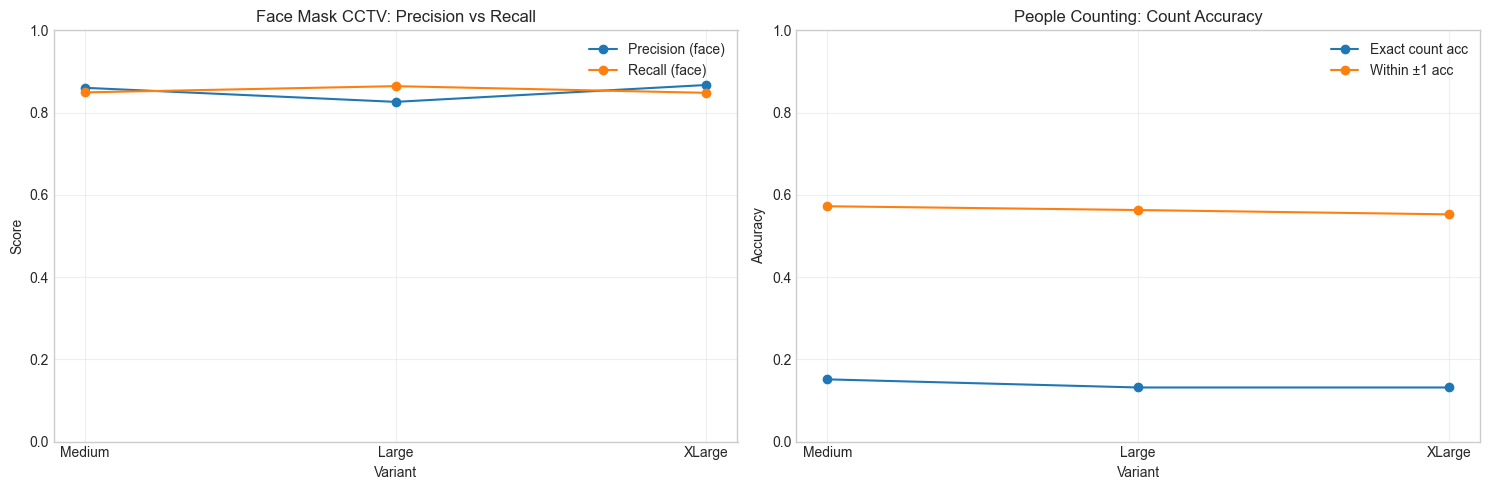

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

pp = combined_perf.dropna(subset=["proxy_exact_count_acc", "proxy_within1_count_acc"]).copy()

# Face detection precision/recall profile.
axes[0].plot(combined_perf["variant_name"], combined_perf["precision_face"], marker="o", label="Precision (face)")
axes[0].plot(combined_perf["variant_name"], combined_perf["recall_face"], marker="o", label="Recall (face)")
axes[0].set_title("Face Mask CCTV: Precision vs Recall")
axes[0].set_xlabel("Variant")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# People counting accuracy profile.
axes[1].plot(pp["variant_name"], pp["proxy_exact_count_acc"], marker="o", label="Exact count acc")
axes[1].plot(pp["variant_name"], pp["proxy_within1_count_acc"], marker="o", label="Within ±1 acc")
axes[1].set_title("People Counting: Count Accuracy")
axes[1].set_xlabel("Variant")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()